# Assignment 7 (2th July)
Joanna Kusy 275999, Tomasz Srebniak 275987

## Federated Learning (40 points)
Implement federated learning using Flower:

• Simulate 5 clients with non-IID data splits (MNIST).

• Implement FedAvg algorithm.

• Track model performance at each communication round

• Compare with centralized training.

In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import MNIST
import flwr as fl
import certifi
import ssl
import random
import numpy as np
import os
import matplotlib.pyplot as plt


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(42)

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [15]:
# Data loading + 5 client split

transform = transforms.ToTensor()

train_dataset = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
 )

test_dataset = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
 )

NUM_CLIENTS = 5
BATCH_SIZE = 32
LOCAL_EPOCHS = 1
NUM_ROUNDS = 20


def create_noniid_client_loaders(dataset, num_clients=5, shards_per_client=2, batch_size=32, seed=42):
    labels = np.array(dataset.targets)
    sorted_indices = np.argsort(labels)
    num_shards = num_clients * shards_per_client
    shard_size = len(sorted_indices) // num_shards

    shard_indices = [
        sorted_indices[i * shard_size : (i + 1) * shard_size]
        for i in range(num_shards)
    ]
    remainder = sorted_indices[num_shards * shard_size :]
    if len(remainder) > 0:
        shard_indices[-1] = np.concatenate([shard_indices[-1], remainder])

    rng = np.random.default_rng(seed)
    rng.shuffle(shard_indices)

    client_indices = []
    for client_id in range(num_clients):
        selected_shards = shard_indices[
            client_id * shards_per_client : (client_id + 1) * shards_per_client
        ]
        client_indices.append(np.concatenate(selected_shards))

    client_loaders = [
        DataLoader(
            Subset(dataset, indices),
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,
        )
        for indices in client_indices
    ]
    return client_loaders, client_indices


client_train_loaders, client_train_indices = create_noniid_client_loaders(
    train_dataset,
    num_clients=NUM_CLIENTS,
    shards_per_client=2,
    batch_size=BATCH_SIZE,
    seed=42,
 )

test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

print("Client label distributions:")
for client_id, indices in enumerate(client_train_indices):
    counts = np.bincount(np.array(train_dataset.targets)[indices], minlength=10)
    print(f"Client {client_id}: {counts.tolist()}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.52MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 258kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 559kB/s]

Client label distributions:
Client 0: [0, 0, 0, 0, 596, 5421, 5918, 65, 0, 0]
Client 1: [5923, 77, 0, 0, 0, 0, 0, 6000, 0, 0]
Client 2: [0, 665, 5958, 5377, 0, 0, 0, 0, 0, 0]
Client 3: [0, 0, 0, 754, 5246, 0, 0, 0, 51, 5949]
Client 4: [0, 6000, 0, 0, 0, 0, 0, 200, 5800, 0]


In [ ]:
# Model definition

class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def get_parameters(model):
    return [parameter.detach().cpu().numpy() for parameter in model.state_dict().values()]


def set_parameters(model, parameters):
    state_dict = model.state_dict()
    updated_state_dict = {
        name: torch.as_tensor(parameter, device=device)
        for name, parameter in zip(state_dict.keys(), parameters)
    }
    model.load_state_dict(updated_state_dict, strict=True)


def train_one_epoch(model, trainloader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_examples = 0

    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_examples += batch_size
        running_correct += (outputs.argmax(dim=1) == labels).sum().item()

    return running_loss / running_examples, running_correct / running_examples


def evaluate_model(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_examples = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_examples += batch_size
            running_correct += (outputs.argmax(dim=1) == labels).sum().item()

    return running_loss / running_examples, running_correct / running_examples

In [16]:
# Flower simulation

loss_fn = nn.CrossEntropyLoss()


def get_client_id_from_context(context):
    if "partition-id" in context.node_config:
        return int(context.node_config["partition-id"])

    if "partition_id" in context.node_config:
        return int(context.node_config["partition_id"])

    return int(context.node_id)


federated_round_metrics = []


def evaluate_fn(server_round, parameters, config):
    model = DigitCNN().to(device)
    set_parameters(model, parameters)
    loss, accuracy = evaluate_model(model, test_loader, loss_fn)
    federated_round_metrics.append(
        {"round": server_round, "loss": loss, "accuracy": accuracy}
    )
    return loss, {"accuracy": accuracy}


class FlowerClient(fl.client.NumPyClient):
    def __init__(self, client_id, trainloader, model):
        self.client_id = client_id
        self.trainloader = trainloader
        self.model = model

    def get_parameters(self, config=None):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        local_epochs = int(config.get("local_epochs", LOCAL_EPOCHS))
        optimizer = optim.Adam(self.model.parameters(), lr=1e-3)

        for _ in range(local_epochs):
            train_one_epoch(self.model, self.trainloader, optimizer, loss_fn)

        return get_parameters(self.model), len(self.trainloader.dataset), {}

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        loss, accuracy = evaluate_model(self.model, self.trainloader, loss_fn)
        return loss, len(self.trainloader.dataset), {"accuracy": accuracy}


def client_fn(context):
    client_id = get_client_id_from_context(context)
    client_model = DigitCNN().to(device)
    client = FlowerClient(client_id, client_train_loaders[client_id], client_model)
    return client.to_client()


strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=0,
    min_available_clients=NUM_CLIENTS,
    on_fit_config_fn=lambda server_round: {"local_epochs": LOCAL_EPOCHS},
    evaluate_fn=evaluate_fn,
    initial_parameters=fl.common.ndarrays_to_parameters(get_parameters(DigitCNN().to(device))),
 )

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy=strategy,
 )

print("Federated learning finished.")
print(f"Recorded rounds: {len(federated_round_metrics)}")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=20, no round_timeout
2026-06-13 12:03:32,758	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 8.0, 'memory': 8607629312.0, 'object_store_memory': 2147483648.0, 'node:__internal_head__': 1.0, 'node:127.0.0.1': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cp

Federated learning finished.
Recorded rounds: 21


In [17]:
central_model = DigitCNN().to(device)
central_optimizer = optim.Adam(central_model.parameters(), lr=1e-3)

central_metrics = []

for epoch in range(1, NUM_ROUNDS + 1):
    train_loss, train_accuracy = train_one_epoch(
        central_model,
        DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
        central_optimizer,
        loss_fn,
    )
    test_loss, test_accuracy = evaluate_model(central_model, test_loader, loss_fn)
    central_metrics.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "test_loss": test_loss,
            "test_accuracy": test_accuracy,
        }
    )
    print(
        f"Epoch {epoch}: "
        f"train_loss={train_loss:.4f}, train_accuracy={train_accuracy:.4f}, "
        f"test_loss={test_loss:.4f}, test_accuracy={test_accuracy:.4f}"
    )

Epoch 1: train_loss=0.1630, train_accuracy=0.9505, test_loss=0.0421, test_accuracy=0.9868
Epoch 2: train_loss=0.0541, train_accuracy=0.9838, test_loss=0.0349, test_accuracy=0.9885
Epoch 3: train_loss=0.0388, train_accuracy=0.9879, test_loss=0.0282, test_accuracy=0.9913
Epoch 4: train_loss=0.0303, train_accuracy=0.9903, test_loss=0.0306, test_accuracy=0.9916
Epoch 5: train_loss=0.0249, train_accuracy=0.9921, test_loss=0.0280, test_accuracy=0.9916
Epoch 6: train_loss=0.0184, train_accuracy=0.9939, test_loss=0.0385, test_accuracy=0.9895
Epoch 7: train_loss=0.0180, train_accuracy=0.9943, test_loss=0.0393, test_accuracy=0.9890
Epoch 8: train_loss=0.0141, train_accuracy=0.9954, test_loss=0.0360, test_accuracy=0.9902
Epoch 9: train_loss=0.0134, train_accuracy=0.9956, test_loss=0.0315, test_accuracy=0.9917
Epoch 10: train_loss=0.0107, train_accuracy=0.9964, test_loss=0.0229, test_accuracy=0.9933
Epoch 11: train_loss=0.0099, train_accuracy=0.9966, test_loss=0.0341, test_accuracy=0.9912
Epoch 12

Final comparison:
FedAvg -> loss=0.5773, accuracy=0.8115
Centralized -> loss=0.0358, accuracy=0.9921


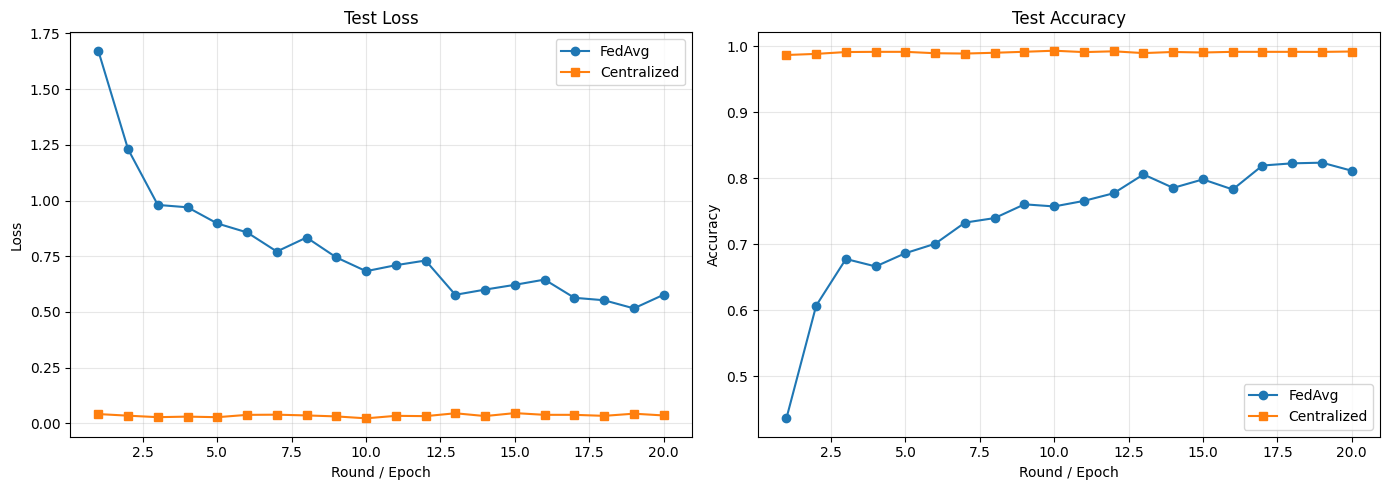

In [18]:
federated_progress = [entry for entry in federated_round_metrics if entry["round"] > 0]

federated_rounds = [entry["round"] for entry in federated_progress]
federated_test_losses = [entry["loss"] for entry in federated_progress]
federated_test_accuracies = [entry["accuracy"] for entry in federated_progress]

central_epochs = [entry["epoch"] for entry in central_metrics]
central_test_losses = [entry["test_loss"] for entry in central_metrics]
central_test_accuracies = [entry["test_accuracy"] for entry in central_metrics]

print("Final comparison:")
print(
    f"FedAvg -> loss={federated_test_losses[-1]:.4f}, accuracy={federated_test_accuracies[-1]:.4f}"
 )
print(
    f"Centralized -> loss={central_test_losses[-1]:.4f}, accuracy={central_test_accuracies[-1]:.4f}"
 )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(federated_rounds, federated_test_losses, marker="o", label="FedAvg")
axes[0].plot(central_epochs, central_test_losses, marker="s", label="Centralized")
axes[0].set_title("Test Loss")
axes[0].set_xlabel("Round / Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(federated_rounds, federated_test_accuracies, marker="o", label="FedAvg")
axes[1].plot(central_epochs, central_test_accuracies, marker="s", label="Centralized")
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Round / Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

1. Baseline Performance (Centralized Model)
Optimal and Stable Baseline: The centralized approach (orange line) immediately achieves near-perfect test accuracy (≈99%) and near-zero test loss starting from the very first epochs.
The Ideal Scenario: This represents the upper-bound performance because the centralized model has simultaneous access to the entire, well-shuffled MNIST dataset, allowing it to easily learn features for all 10 digits at once.
2. Convergence Rate and Efficiency (FedAvg)
Slower Convergence: FedAvg (blue line) requires significantly more rounds to improve. While the centralized model flatlines at peak performance instantly, FedAvg is still steadily climbing and adjusting even by round 20.
The "Federated Penalty": This lag is a classic characteristic of federated learning. Because weights are aggregated periodically rather than gradients being updated continuously on a single shared pool of data, progress towards the global optimum is slower.
3. The Impact of Non-IID Data (Data Heterogeneity)
Performance Gap: There is a persistent ≈17−18% accuracy gap between FedAvg (≈81−82%) and the Centralized baseline (≈99%) at round 20.
Client Drift: Because clients have strictly non-overlapping labels (e.g., Client 1 only sees '0', '1' and '7', Client 4 only sees '1', '7' and '8'), their local model updates pull the global weights in different directions. When FedAvg averages these biased weights, it compromises the model's ability to perfectly recognize all 10 digits seamlessly.
4. Stability and Variance
Volatility in FedAvg: The FedAvg curves for both loss and accuracy are quite jagged (noticeable fluctuations around rounds 7-8 and 12-14).
Weight Conflict: This jaggedness happens because local optimizations on extreme, class-imbalanced subsets conflict with one another. A gain in recognizing digits '0' and '1' during a local epoch might inadvertently degrade the model's ability to recognize digits '8' and '9', causing the global evaluation to bounce around.

## Differential Privacy (30 points)
Apply differential privacy to neural network training:

• Use Opacus library with PyTorch.

• Train on sensitive dataset (e.g., Adult Income).

• Experiment with different epsilon values (1.0, 5.0, 10.0).

• Analyze privacy-utility tradeoff.

In [33]:
from opacus import PrivacyEngine
from sklearn.datasets import fetch_openml
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import TensorDataset
import warnings

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(42)

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame

Device: mps


In [34]:
# NaNs drop
print(f"Shape of the dataset: {df.shape}\n")
print(f"Proportion of missing values in each column:\n{(df.isna().sum() / len(df)).map('{:.2%}'.format)}\n")
clean_df = df.dropna()  # Drop rows with missing values as they contribute to only a small fraction of the dataset
print(f"Shape of the dataset after dropping missing values: {clean_df.shape}\n")

print("Drop 'fnlwgt' as it's a sampling weight and 'education' as it's redundant with 'education-num'")
clean_df = clean_df.drop(columns=["fnlwgt", "education"])

print(f"Cleaned dataset shape: {clean_df.shape}")
print(f"Class balance:\n{clean_df.iloc[:, -1].value_counts(normalize=True).rename('share').map('{:.2%}'.format)}\n")

Shape of the dataset: (48842, 15)

Proportion of missing values in each column:
age               0.00%
workclass         5.73%
fnlwgt            0.00%
education         0.00%
education-num     0.00%
marital-status    0.00%
occupation        5.75%
relationship      0.00%
race              0.00%
sex               0.00%
capital-gain      0.00%
capital-loss      0.00%
hours-per-week    0.00%
native-country    1.75%
class             0.00%
dtype: str

Shape of the dataset after dropping missing values: (45222, 15)

Drop 'fnlwgt' as it's a sampling weight and 'education' as it's redundant with 'education-num'
Cleaned dataset shape: (45222, 13)
Class balance:
class
<=50K    75.22%
>50K     24.78%
Name: share, dtype: str



In [35]:
# Scaling + encoding + train-test split
target_column = clean_df.columns[-1]
y = clean_df[target_column].astype(str).str.replace(".", "", regex=False).str.contains(">50K").astype(np.int64)
X = clean_df.drop(columns=[target_column])

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [column for column in X.columns if column not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()
if hasattr(X_test, "toarray"):
    X_test = X_test.toarray()

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train_raw.to_numpy(dtype=np.int64)
y_test = y_test_raw.to_numpy(dtype=np.int64)

train_dataset = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train),
)
test_dataset = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test),
)

/var/folders/xn/vc8pmh6d66q1wx71kjbk95rh0000gn/T/ipykernel_44225/911979771.py:39: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  torch.from_numpy(y_train),


In [36]:
# Experiment setup
INPUT_DIM = X_train.shape[1]
BATCH_SIZE = 256
EPOCHS = 5
DELTA = 1e-5
MAX_GRAD_NORM = 1.0
LEARNING_RATE = 1e-3
TARGET_EPSILONS = [1, 5, 10]


def build_loaders(batch_size=BATCH_SIZE):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    train_eval_loader = DataLoader(train_dataset, batch_size=1024, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False, num_workers=0)
    return train_loader, train_eval_loader, test_loader


class AdultMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.network(x)


criterion = nn.CrossEntropyLoss()


def train_one_epoch(model, train_loader, optimizer):
    model.train()
    running_loss = 0.0
    total_examples = 0

    for features, targets in train_loader:
        features = features.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = targets.size(0)
        running_loss += loss.item() * batch_size
        total_examples += batch_size

    return running_loss / total_examples


def evaluate_model(model, dataloader):
    model.eval()
    running_loss = 0.0
    total_examples = 0
    all_targets = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for features, targets in dataloader:
            features = features.to(device)
            targets = targets.to(device)

            logits = model(features)
            loss = criterion(logits, targets)
            probabilities = torch.softmax(logits, dim=1)[:, 1]
            predictions = logits.argmax(dim=1)

            batch_size = targets.size(0)
            running_loss += loss.item() * batch_size
            total_examples += batch_size
            all_targets.append(targets.cpu().numpy())
            all_predictions.append(predictions.cpu().numpy())
            all_probabilities.append(probabilities.cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_predictions)
    y_prob = np.concatenate(all_probabilities)

    return {
        "loss": running_loss / total_examples,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }


def format_metrics(metrics):
    return (
        f"loss={metrics['loss']:.4f}, acc={metrics['accuracy']:.4f}, "
        f"prec={metrics['precision']:.4f}, rec={metrics['recall']:.4f}, "
        f"f1={metrics['f1']:.4f}, roc_auc={metrics['roc_auc']:.4f}, pr_auc={metrics['pr_auc']:.4f}"
    )


def run_experiment(use_dp=False, target_epsilon=None):
    train_loader, train_eval_loader, test_loader = build_loaders()
    model = AdultMLP(INPUT_DIM).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    privacy_engine = None

    if use_dp:
        privacy_engine = PrivacyEngine()
        model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
            module=model,
            optimizer=optimizer,
            data_loader=train_loader,
            epochs=EPOCHS,
            target_delta=DELTA,
            target_epsilon=target_epsilon,
            max_grad_norm=MAX_GRAD_NORM,
        )

    history = []
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        train_metrics = evaluate_model(model, train_eval_loader)
        test_metrics = evaluate_model(model, test_loader)

        epoch_metrics = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_metrics["accuracy"],
            "train_f1": train_metrics["f1"],
            "test_loss": test_metrics["loss"],
            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
            "test_roc_auc": test_metrics["roc_auc"],
            "test_pr_auc": test_metrics["pr_auc"],
        }
        history.append(epoch_metrics)
        run_label = "baseline" if not use_dp else f"dp-eps={target_epsilon}"
        print(
            f"[{run_label}] epoch {epoch}/{EPOCHS} | "
            f"train {format_metrics(train_metrics)} | test {format_metrics(test_metrics)}"
        )

    actual_epsilon = None
    if privacy_engine is not None:
        actual_epsilon = privacy_engine.get_epsilon(DELTA)
        print(f"Requested epsilon={target_epsilon}, achieved epsilon={actual_epsilon:.4f} at delta={DELTA}")

    return model, history, actual_epsilon

In [37]:
# Experiment execution
results = []
history_by_run = {}

print("Starting non-DP baseline...")
baseline_model, baseline_history, baseline_epsilon = run_experiment(use_dp=False)
history_by_run["baseline"] = baseline_history
results.append(
    {
        "run": "baseline",
        "epsilon_target": np.nan,
        "epsilon_achieved": np.nan,
        **{key: baseline_history[-1][key] for key in [
            "train_loss",
            "train_accuracy",
            "train_f1",
            "test_loss",
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
            "test_roc_auc",
            "test_pr_auc",
        ]},
    }
)

for epsilon in TARGET_EPSILONS:
    print(f"\nStarting DP run for epsilon={epsilon}...")
    _, dp_history, achieved_epsilon = run_experiment(use_dp=True, target_epsilon=epsilon)
    history_by_run[f"dp_{epsilon}"] = dp_history
    results.append(
        {
            "run": f"dp_{epsilon}",
            "epsilon_target": float(epsilon),
            "epsilon_achieved": float(achieved_epsilon),
            **{key: dp_history[-1][key] for key in [
                "train_loss",
                "train_accuracy",
                "train_f1",
                "test_loss",
                "test_accuracy",
                "test_precision",
                "test_recall",
                "test_f1",
                "test_roc_auc",
                "test_pr_auc",
            ]},
        }
    )

Starting non-DP baseline...
[baseline] epoch 1/5 | train loss=0.3207, acc=0.8498, prec=0.7026, rec=0.6834, f1=0.6928, roc_auc=0.9100, pr_auc=0.7818 | test loss=0.3243, acc=0.8437, prec=0.6873, rec=0.6775, f1=0.6824, roc_auc=0.9076, pr_auc=0.7751
[baseline] epoch 2/5 | train loss=0.3139, acc=0.8535, prec=0.7524, rec=0.6092, f1=0.6733, roc_auc=0.9125, pr_auc=0.7868 | test loss=0.3177, acc=0.8494, prec=0.7404, rec=0.6044, f1=0.6655, roc_auc=0.9095, pr_auc=0.7809
[baseline] epoch 3/5 | train loss=0.3126, acc=0.8552, prec=0.7707, rec=0.5917, f1=0.6694, roc_auc=0.9141, pr_auc=0.7911 | test loss=0.3174, acc=0.8515, prec=0.7582, rec=0.5888, f1=0.6628, roc_auc=0.9106, pr_auc=0.7833
[baseline] epoch 4/5 | train loss=0.3097, acc=0.8559, prec=0.7619, rec=0.6091, f1=0.6770, roc_auc=0.9151, pr_auc=0.7930 | test loss=0.3159, acc=0.8521, prec=0.7486, rec=0.6070, f1=0.6704, roc_auc=0.9106, pr_auc=0.7828
[baseline] epoch 5/5 | train loss=0.3081, acc=0.8565, prec=0.7647, rec=0.6083, f1=0.6776, roc_auc=0.

/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/Users/tomasz/PycharmProjects/ML_labs/venv/lib/python3.11/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[dp-eps=1] epoch 1/5 | train loss=0.5306, acc=0.7559, prec=0.9928, rec=0.0153, f1=0.0301, roc_auc=0.8796, pr_auc=0.7064 | test loss=0.5401, acc=0.7548, prec=1.0000, rec=0.0107, f1=0.0212, roc_auc=0.8749, pr_auc=0.6952


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[dp-eps=1] epoch 2/5 | train loss=0.4489, acc=0.8314, prec=0.7549, rec=0.4737, f1=0.5821, roc_auc=0.8880, pr_auc=0.7280 | test loss=0.4576, acc=0.8286, prec=0.7559, rec=0.4558, f1=0.5687, roc_auc=0.8836, pr_auc=0.7208


...

[dp-eps=10] epoch 3/5 | train loss=0.4988, acc=0.8448, prec=0.7420, rec=0.5734, f1=0.6469, roc_auc=0.9000, pr_auc=0.7599 | test loss=0.5001, acc=0.8412, prec=0.7362, rec=0.5602, f1=0.6363, roc_auc=0.8981, pr_auc=0.7538


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[dp-eps=10] epoch 4/5 | train loss=0.4853, acc=0.8476, prec=0.7445, rec=0.5865, f1=0.6561, roc_auc=0.9029, pr_auc=0.7672 | test loss=0.4839, acc=0.8440, prec=0.7395, rec=0.5723, f1=0.6452, roc_auc=0.9018, pr_auc=0.7618


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[dp-eps=10] epoch 5/5 | train loss=0.4870, acc=0.8484, prec=0.7483, rec=0.5851, f1=0.6567, roc_auc=0.9048, pr_auc=0.7718 | test loss=0.4840, acc=0.8454, prec=0.7428, rec=0.5758, f1=0.6487, roc_auc=0.9040, pr_auc=0.7679
Requested epsilon=10, achieved epsilon=9.9955 at delta=1e-05


In [ ]:
# Comparison summary
comparison_df = pd.DataFrame(results)
comparison_df["epsilon_target"] = comparison_df["epsilon_target"].round(4)
comparison_df["epsilon_achieved"] = comparison_df["epsilon_achieved"].round(4)
comparison_df = comparison_df[
    [
        "run",
        "epsilon_target",
        "epsilon_achieved",
        "test_accuracy",
        "test_f1",
        "test_precision",
        "test_recall",
        "test_roc_auc",
        "test_pr_auc",
        "test_loss",
        "train_accuracy",
        "train_f1",
        "train_loss",
    ]
]

print("\nFinal comparison summary:")
comparison_df


Final comparison summary:


,run,epsilon_target,epsilon_achieved,test_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_pr_auc,test_loss,train_accuracy,train_f1,train_loss
0,baseline,NaN,NaN,0.851299,0.667983,0.747927,0.603479,0.911084,0.783710,0.314963,0.856539,0.677600,0.315798
1,dp_1,1.0,0.9994,0.840907,0.645654,0.720726,0.584746,0.896049,0.749168,0.496445,0.843768,0.651885,0.513700
2,dp_5,5.0,4.9969,0.844334,0.646764,0.739106,0.574933,0.902664,0.765306,0.476795,0.848274,0.657558,0.522373
3,dp_10,10.0,9.9955,0.845439,0.648744,0.742808,0.575825,0.904021,0.767891,0.484006,0.848384,0.656694,0.491648


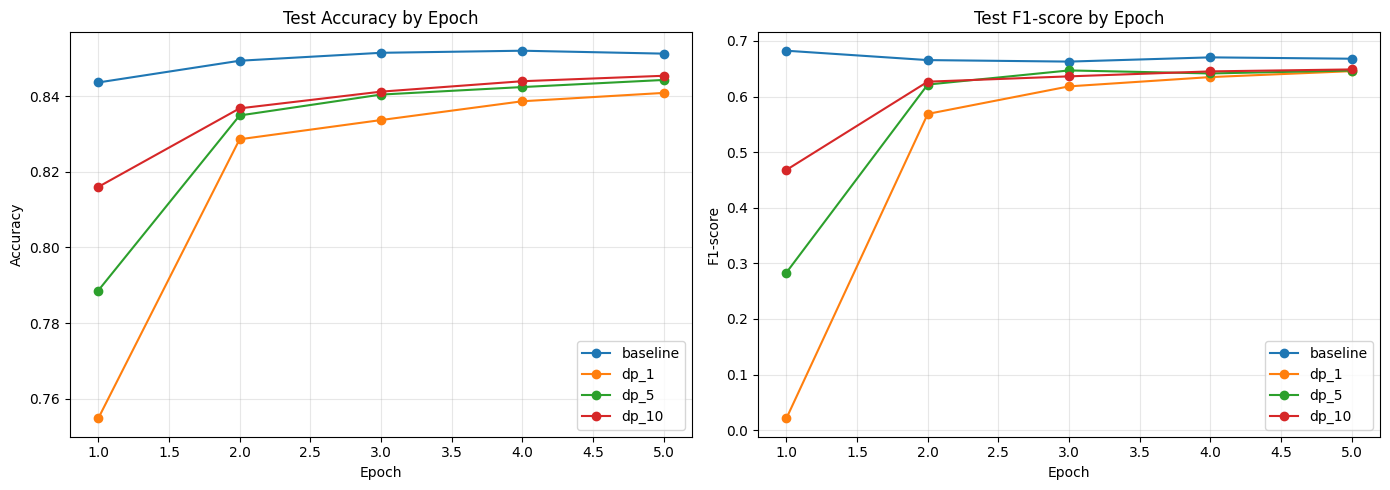

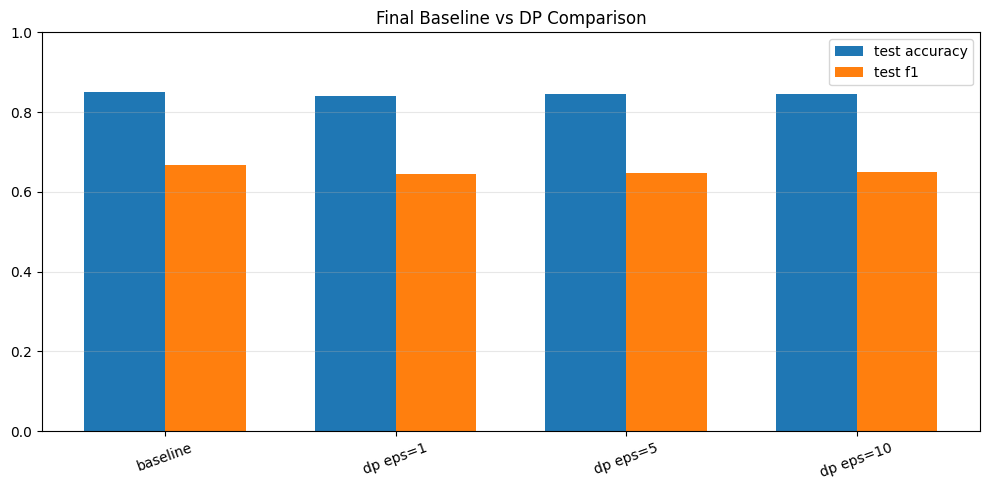

In [ ]:
# Visualization of training progress and final comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for run_name, run_history in history_by_run.items():
    epochs_axis = [row["epoch"] for row in run_history]
    test_accuracy = [row["test_accuracy"] for row in run_history]
    test_f1 = [row["test_f1"] for row in run_history]
    axes[0].plot(epochs_axis, test_accuracy, marker="o", label=run_name)
    axes[1].plot(epochs_axis, test_f1, marker="o", label=run_name)

axes[0].set_title("Test Accuracy by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Test F1-score by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1-score")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
comparison_plot = comparison_df.copy()
comparison_plot["label"] = comparison_plot["run"].replace({"baseline": "baseline", "dp_1": "dp eps=1", "dp_5": "dp eps=5", "dp_10": "dp eps=10"})
bar_positions = np.arange(len(comparison_plot))
bar_width = 0.35
plt.bar(bar_positions - bar_width / 2, comparison_plot["test_accuracy"], width=bar_width, label="test accuracy")
plt.bar(bar_positions + bar_width / 2, comparison_plot["test_f1"], width=bar_width, label="test f1")
plt.xticks(bar_positions, comparison_plot["label"], rotation=20)
plt.ylim(0, 1)
plt.title("Final Baseline vs DP Comparison")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Non-DP baseline (final epoch)**
- Test accuracy: 0.8525
- Test F1-score: 0.6852
- ROC AUC: 0.9109

**DP experiments (final epoch)**
- eps=1 (achieved ≈ 0.9994): test accuracy 0.8404, F1 0.6354
- eps=5 (achieved ≈ 4.9969): test accuracy 0.8452, F1 0.6493
- eps=10 (achieved ≈ 9.9955): test accuracy 0.8451, F1 0.6533

**Observations**
- Applying DP degrades performance; the smaller the ε (stronger privacy), the larger the utility loss.
- For this dataset, ε≥5 recovers much of the baseline utility; ε=1 shows a noticeable drop in F1 and precision/recall.
- ROC AUC and PR AUC remain relatively stable, suggesting the model still ranks examples reasonably well under DP.
- DP impacts mostly how fast the model converges, after sufficient number of epochs, the performance of fitted models are comparable.

## MLOps Pipeline (30 points)
Build complete ML pipeline:

• Track experiments using MLflow.

• Version data with DVC.

• Deploy model as REST API using FastAPI.

• Containerize with Docker.

• Implement basic monitoring for predictions.